In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import os
from utils import read_scale, loadBCs
import time

In [4]:
def renorm(data, scale_length, boxsize):
    N = boxsize**3/scale_length**3
    return data * scale_length[None, :, None]**3 /N[None, :, None]


In [37]:
# 存储scale length

sub = True
fof = True

redshift = 'z0.5'
bc_file_end = '.bc'

overwrite = True
# sims = ['fiducial_ZA', 'h_m', 'h_p', 'ns_m', 'ns_p', 'w_m', 'w_p']
# sims = complete
sims = ['s8_m']

if fof:
    save_root = '/hscratch/ljy/ProcessedFoFData'
else:
    save_root = '/hscratch/ljy/ProcessedData'


for sim in sims:
    sim_dir = os.path.join(save_root, sim)
    
    processed_dir = os.path.join(sim_dir, redshift)

    file_name = f'{sim}'

    if fof:
        file_name += '_fof'
    if sub:
        file_name += '_sub'
        bc_file_end = '.bcsub'
        
    target_name = redshift + bc_file_end      
    file_name += '.npy'


    save_path = os.path.join('/home/ljy/BettiCurveCosmo/Data/TestData/scale_length', file_name)
    if os.path.exists(save_path) and not overwrite:
        print(f'{save_path} already exists')
        continue
    
    scales = read_scale(processed_dir, target=target_name)

    if scales.shape[0] == 0:
        print(f'{sim} has no bc file')
        continue

    np.save(save_path, scales)
    print(f'Saved {save_path}')


Saved /home/ljy/BettiCurveCosmo/Data/TestData/scale_length/s8_m_fof_sub.npy


In [39]:
# 整合并约化bc数据
sub = True
bc_file_end = '.bc' if not sub else '.bcsub'
boxsize = 1000 if not sub else 368
fof = True
# rsd = 'z'
rsd = None
norm = True

overwrite = True

redshift = 'z0.5'

# sims = complete

sims = ['s8_m']

save_dir = '/home/ljy/BettiCurveCosmo/Data/TestData/DimlessBC'
scale_path = '/home/ljy/BettiCurveCosmo/Data/TestData/scale_length'

if rsd is not None:
    target_name = f'rsd{rsd}' + bc_file_end
else:
    target_name = redshift + bc_file_end

if fof:
    data_root = '/hscratch/ljy/ProcessedFoFData'
else:
    data_root = '/hscratch/ljy/ProcessedData'


for sim in sims:
    sim_dir = os.path.join(data_root, sim, redshift)
    file_name = f'{sim}'
    scale_file_name = f'{sim}'
    if fof:
        file_name += '-fof'
        scale_file_name += '_fof'
    if rsd is not None:
        file_name += f'-rsd{rsd}'
    if sub:
        file_name += '-bcsub'
        scale_file_name += '_sub'
    else:
        file_name += '-bc'

    save_path = os.path.join(save_dir, f'{file_name}.npy')

    if os.path.exists(save_path) and not overwrite:
        print(f'{save_path} already exists')
        continue
    
    # 读取scale length
    scale_file = os.path.join(scale_path, f'{scale_file_name}.npy')
    if not os.path.exists(scale_file):
        print(f'{scale_file} does not exist')
        continue

    scales = np.load(scale_file)
    bcs = loadBCs(sim_dir, target=target_name)

    if norm:
        bcs_norm = renorm(bcs, scales, boxsize)
    else:
        bcs_norm = bcs
        
    np.save(save_path, bcs_norm)
    print(f'Saved {save_path}')

Saved /home/ljy/BettiCurveCosmo/Data/TestData/DimlessBC/s8_m-fof-bcsub.npy


In [34]:
def load_bcs_as_dict(sims, save_dir, bc_file_str, fof=True, rsd=None):
    bcs = {}
    for sim in sims:
        file_name = f'{sim}'
        if fof:
            file_name += '-fof'
        if rsd is not None:
            file_name += f'-rsd{rsd}'
        file_name += f'{bc_file_str}.npy'
        bcs[sim] = np.load(os.path.join(save_dir, file_name))[:,-500:,:]
        print(f'{file_name}: {bcs[sim].shape}')
    return bcs

def parameter_derivative(bcs, save_root=None, fof=True, rsd=None):
    dbcs = {}
    params = ['Om', 'Ob2', 'h', 'ns', 's8', 'w', 'Mnu']
    params_intervals = {'h':0.02, 'ns':0.02, 's8':0.015, 'Ob2':0.002, 'Om':0.01, 'w':0.05, 'Mnu':0.1}
    for param in params:
        if param == 'Mnu':
            key_p = 'Mnu_pp'
            key_m = 'Mnu_p'
            if key_p not in bcs or key_m not in bcs:
                print(f'{param} does not exist')
                continue
            bc_p = bcs[key_p]
            bc_m = bcs[key_m]
        else:
            key_p = param+'_p'
            key_m = param+'_m'
            if key_p not in bcs or key_m not in bcs:
                print(f'{param} does not exist')
                continue
            bc_p = bcs[key_p]
            bc_m = bcs[key_m]
        
        if bc_m is None or bc_p is None:
            print(f'{param} does not exist')
            continue

        print(f'{param} : {bc_p.shape}')

        dbcs[param] = (bc_p - bc_m)/(2*params_intervals[param])

        if save_root is not None:
            file_name = f'{param}'
            if fof:
                file_name += '_fof'
            if rsd is not None:
                file_name += f'_rsd{rsd}'
            file_name += '_dbc.npy'

            np.save(os.path.join(save_root, file_name), dbcs[param])

    return dbcs

In [ ]:
sub = True
bc_file_str = '-bc' if not sub else '-bcsub'

save_dir = '/home/ljy/BettiCurveCosmo/Data/TestData/DimlessBC'
dbc_save_dir = '/home/ljy/BettiCurveCosmo/Data/TestData/DimlessBC/derivative'
# dbc_save_dir = None

sims = ['Ob2_p',
 'Mnu_pp',
 's8_p',
 'fiducial_ZA',
 'fiducial',
 'Om_p',
 'w_p',
 's8_m',
 'Om_m',
 'Ob2_m',
 'ns_m',
 'h_m',
 'h_p',
 'Mnu_p',
 'w_m',
 'ns_p']

bcs_fof = load_bcs_as_dict(sims, save_dir, bc_file_str, fof=True, rsd=None)
dbcs_fof = parameter_derivative(bcs_fof, save_root=dbc_save_dir, fof=True, rsd=None)

bcs_fof_rsdz = load_bcs_as_dict(sims, save_dir, bc_file_str, fof=True, rsd='z')
dbcs_fof_rsdz = parameter_derivative(bcs_fof_rsdz, save_root=dbc_save_dir, fof=True, rsd='z')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


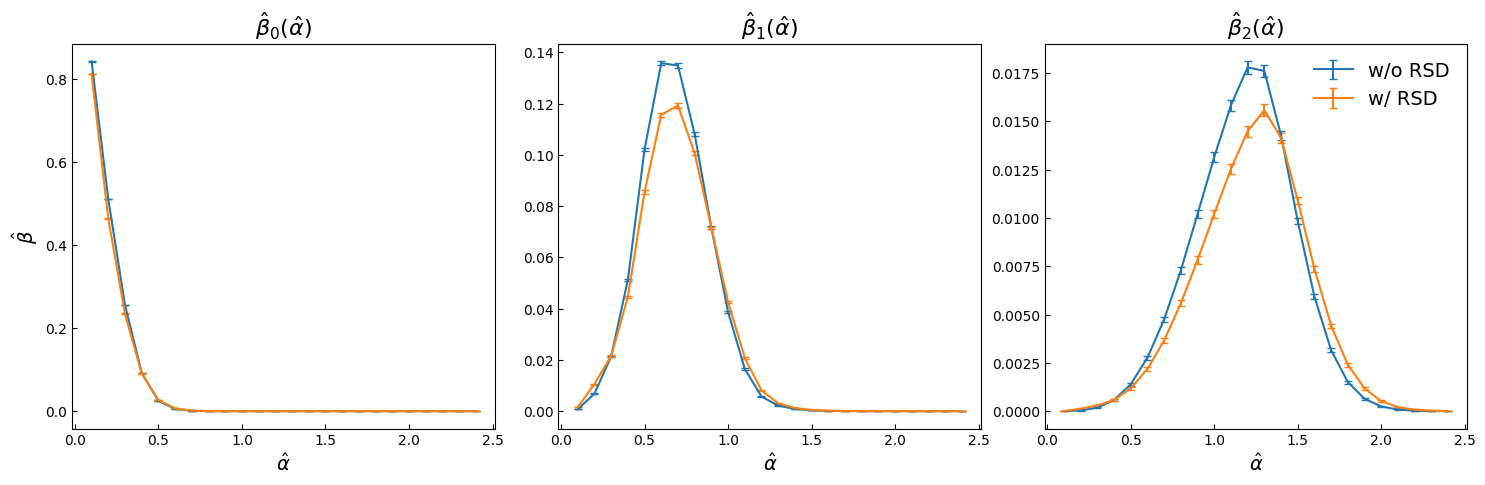

In [6]:
x = np.arange(0.1,2.5,0.1)
fig, axes = plt.subplots(1,3, figsize=(18, 5))
for i in range(3):
    axes[i].errorbar(x, np.mean(bcs_fof['fiducial'][i], axis=0)[1:], yerr=np.std(bcs_fof['fiducial'][i], axis=0)[1:], label='w/o RSD', capsize=3)
    axes[i].errorbar(x, np.mean(bcs_fof_rsdz['fiducial'][i], axis=0)[1:], yerr=np.std(bcs_fof_rsdz['fiducial'][i], axis=0)[1:], label='w/ RSD', capsize=3)

    if i == 0:
        axes[i].set_ylabel(r'$\hat{\beta}$', fontsize=14) 
    axes[i].set_xlabel(r'$\hat{\alpha}$', fontsize=14)
    axes[i].set_title(fr'$\hat{{\beta}}_{i}(\hat{{\alpha}})$', fontsize=16)
    axes[2].legend(frameon=False, fontsize=14)
    axes[i].tick_params(axis='both', direction='in')
plt.subplots_adjust(wspace=0.15)

plt.savefig('/home/ljy/BettiCurveCosmo/Fig/rsd_comparison.pdf', bbox_inches='tight')
plt.show()
    

In [ ]:
# fileroot = '../Data/TestData/DimlessBC'
# dbcs = {} # numerical derivative
# params = ['Om', 'Ob2', 'h', 'ns', 's8', 'w', 'Mnu']
# params_intervals = {'h':0.02, 'ns':0.02, 's8':0.015, 'Ob2':0.002, 'Om':0.01, 'w':0.05, 'Mnu':0.1}
# for param in params:
#     if param == 'Mnu':
#         bc_p = np.load(fileroot+f"/{param}_pp-bc.npy")
#         bc_m = np.load(fileroot+f"/{param}_p-bc.npy")
#     else:
#         bc_p = np.load(fileroot+f"/{param}_p-bc.npy")
#         bc_m = np.load(fileroot+f"/{param}_m-bc.npy")
#     dbcs[param] = (bc_p - bc_m)/(2*params_intervals[param])
#     np.save(fileroot + "/derivative/" + f"{param}_dbc.npy", dbcs[param])

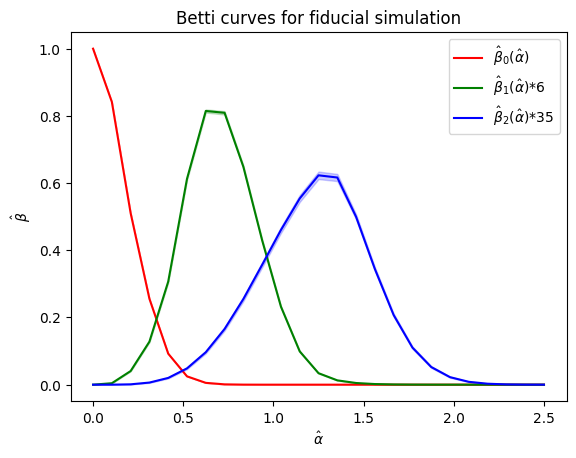

In [ ]:
# Figure 1

data = np.load('../Data/TestData/DimlessBC/fiducial-fof-bc.npy')
x = np.linspace(0,2.5,25)
colors = ['r', 'g', 'b']
factor = [1,6,35]
for dim in range(3):
    std = np.std(data[dim], axis=0)
    if dim == 0:
            plt.fill_between(x, np.mean(data[dim], axis=0)*factor[dim]-std*factor[dim], np.mean(data[dim], axis=0)*factor[dim]+std*factor[dim], color=colors[dim], alpha=0.2)
            plt.plot(x, np.mean(data[dim], axis=0)*factor[dim], color=colors[dim], label=fr'$\hat{{\beta}}_{{{dim}}}(\hat{{\alpha}})$')
    else:
        plt.fill_between(x, np.mean(data[dim], axis=0)*factor[dim]-std*factor[dim], np.mean(data[dim], axis=0)*factor[dim]+std*factor[dim], color=colors[dim], alpha=0.2)
        plt.plot(x, np.mean(data[dim], axis=0)*factor[dim], color=colors[dim], label=fr'$\hat{{\beta}}_{{{dim}}}(\hat{{\alpha}})$*{factor[dim]}')
    plt.xlabel(r'$\hat{\alpha}$')
    plt.ylabel(r'$\hat{\beta}$')

plt.title(f"Betti curves for fiducial simulation")
plt.legend()
plt.savefig('/home/ljy/BettiCurveCosmo/BettiCurveCalaulation/fig/BettiCurves.pdf')
plt.show()

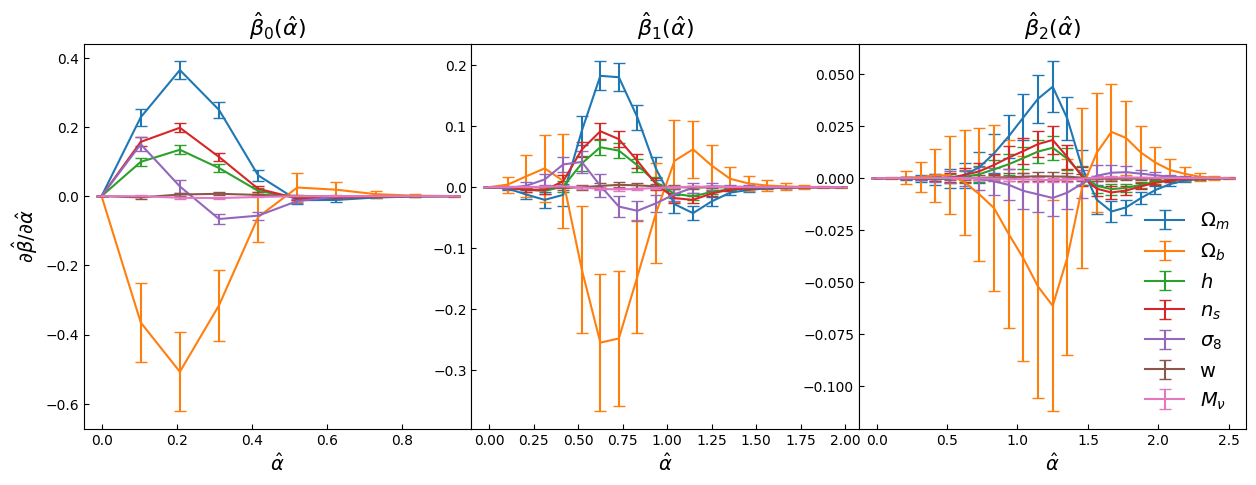

In [25]:

# fof
# fileroot = '../Data/TestData/DimlessBC/derivative'
normlize_by_err = False
x = np.linspace(0,2.5,25)
cuts = [range(0,10), range(0,20),range(0,25)]
params = ['Om', 'Ob2', 'h', 'ns', 's8', 'w', 'Mnu']
labels = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$', r'w', r'$M_{\nu}$']
# params = ['w', 'Mnu']
# labels = [r'w', r'$M_{\nu}$']

fig = plt.figure(figsize=(15,5), dpi=100)
axes = fig.subplots(1,3)

for dim in range(3):
    for param in params:
        if param not in dbcs_fof:
            print(f"{param} does not exist")
            continue
        data = dbcs_fof[param]
        # file = os.path.join(fileroot, param + '_dbc.npy')
        # data = np.load(file)
        mean = np.mean(data[dim], axis=0)[cuts[dim]]
        std = np.std(data[dim], axis=0)[cuts[dim]]
        if normlize_by_err:
            mean /= std
            axes[dim].axhline(0, color='grey', linestyle='--', linewidth=1)
            axes[dim].plot(x[cuts[dim]], mean, label=labels[params.index(param)], linewidth=1.5)
            ylabel = r'$\frac{{\partial\hat{\beta}}/{\partial\hat{\alpha}}}{\sigma_{\hat \beta}}$'   
        else:
            axes[dim].errorbar(x[cuts[dim]], mean, yerr=std, label=labels[params.index(param)], capsize=4, linewidth=1.5)
            ylabel = r'${\partial\hat{\beta}}/{\partial\hat{\alpha}}$'
        axes[dim].set_xlabel(r'$\hat{\alpha}$', fontsize=14)
        if dim == 0:
            axes[dim].set_ylabel(ylabel, fontsize=14)
        axes[dim].set_title(fr'$\hat{{\beta}}_{dim}(\hat{{\alpha}})$', fontsize=16)
        if dim == 2:
            axes[dim].legend(frameon=False, loc='lower right', fontsize=14)
        axes[dim].tick_params(axis='both', direction='in')
plt.subplots_adjust(wspace=0.0)
plt.savefig('../Fig/derivative_fof.pdf', bbox_inches='tight')

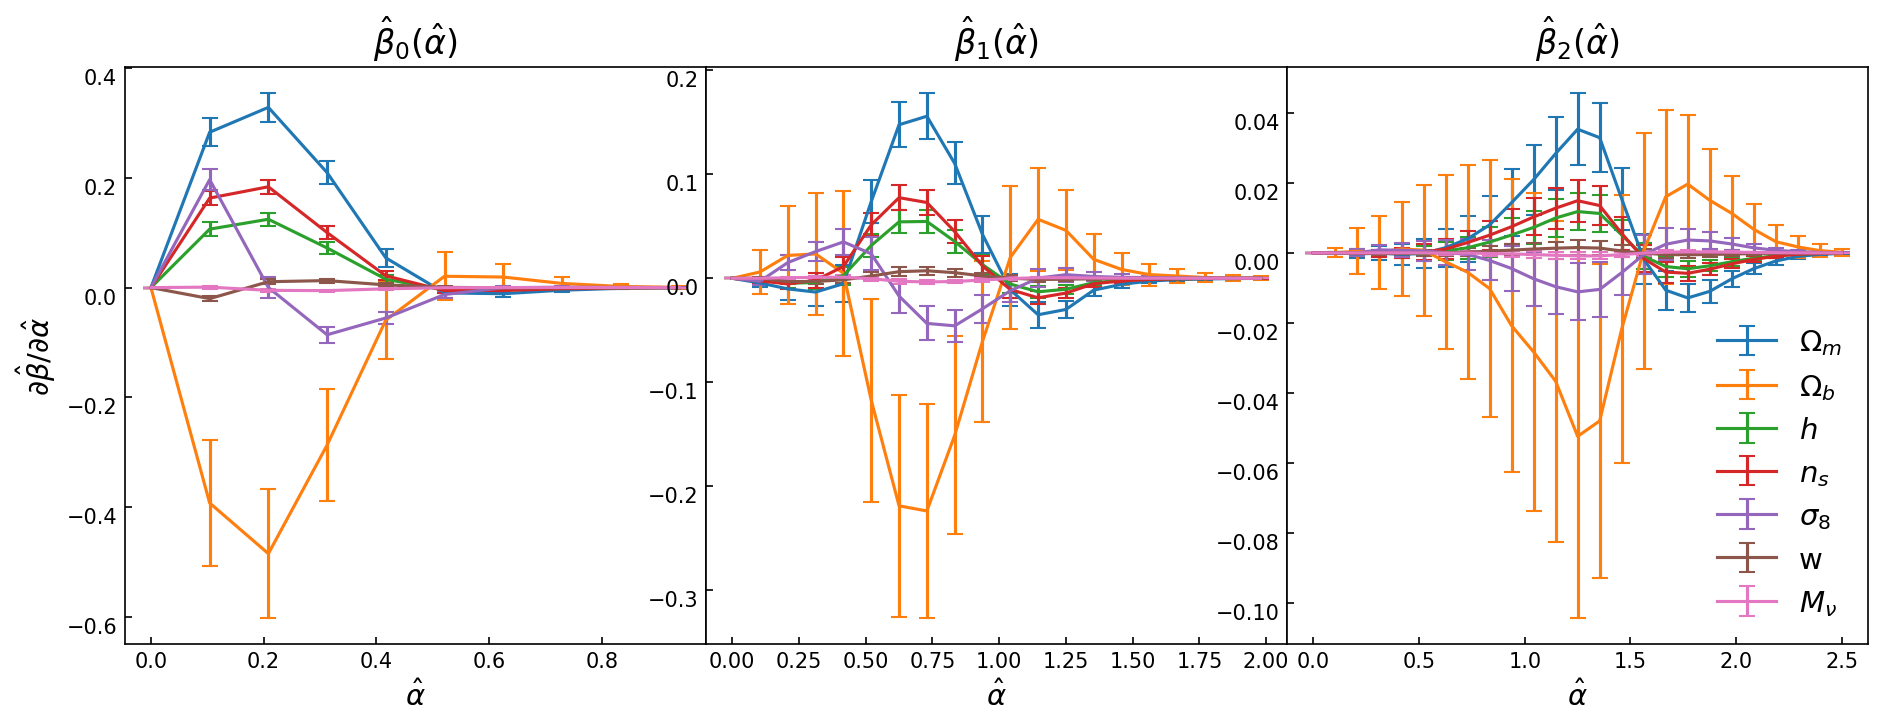

In [36]:
# fof rsdz
normlize_by_err = False
x = np.linspace(0,2.5,25)
cuts = [range(0,10), range(0,20),range(0,25)]
params = ['Om', 'Ob2', 'h', 'ns', 's8', 'w', 'Mnu']
labels = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$', r'w', r'$M_{\nu}$']
# params = ['w', 'Mnu']
# labels = [r'w', r'$M_{\nu}$']

fig = plt.figure(figsize=(15,5), dpi=150)
axes = fig.subplots(1,3)


for dim in range(3):
    for param in params:
        if param not in dbcs_fof_rsdz:
            print(f"{param} does not exist")
            continue
        data = dbcs_fof_rsdz[param]
        # file = os.path.join(fileroot, param + '_dbc.npy')
        # data = np.load(file)
        mean = np.mean(data[dim], axis=0)[cuts[dim]]
        std = np.std(data[dim], axis=0)[cuts[dim]]
        if normlize_by_err:
            mean /= std
            axes[dim].axhline(0, color='grey', linestyle='--', linewidth=1)
            axes[dim].plot(x[cuts[dim]], mean, label=labels[params.index(param)], linewidth=1.5)
            ylabel = r'$\frac{{\partial\hat{\beta}}/{\partial\hat{\alpha}}}{\sigma_{\hat \beta}}$'   
        else:
            axes[dim].errorbar(x[cuts[dim]], mean, yerr=std, label=labels[params.index(param)], capsize=4, linewidth=1.5)
            ylabel = r'${\partial\hat{\beta}}/{\partial\hat{\alpha}}$'
        axes[dim].set_xlabel(r'$\hat{\alpha}$', fontsize=14)
        if dim == 0:
            axes[dim].set_ylabel(ylabel, fontsize=14)
        axes[dim].set_title(fr'$\hat{{\beta}}_{dim}(\hat{{\alpha}})$', fontsize=16)
        if dim == 2:
            axes[dim].legend(frameon=False, loc='lower right', fontsize=14)
        axes[dim].tick_params(axis='both', direction='in')
        for label in axes[dim].get_yticklabels():
            label.set_verticalalignment('top')

plt.subplots_adjust(wspace=0.0)

plt.savefig('../Fig/derivative_fof_rsdz.pdf', bbox_inches='tight')

In [26]:
def cut_data(bcs, cuts=[None, None, None], save_dir=None):
    """
    file extension should be .npz 
    """
    bcs_out = []
    for cut, bc in zip(cuts, bcs):
        if cut is not None:
            bc = bc[:,cut]
        bcs_out.append(bc)

    return bcs_out

def cov(bcs, cuts=[None, None, None], save_dir=None):
    """
    file extension should be .npz 
    """
    bcs_out = []
    for cut, bc in zip(cuts, bcs):
        if cut is not None:
            bc = bc[:,cut]
        bcs_out.append(bc)
    covs = [np.cov(np.array(bc).T) for bc in bcs_out]
    
    if save_dir is not None:
        covarray = {'0' : covs[0], '1' : covs[1], '2' : covs[2]}
        np.savez(save_dir, **covarray) # np.save() requires array doesn't have inhomogeneous shape

    return bcs_out, covs

def sens_plot(x, fiducial_data, fiducialZA_data, test_datas, test_datasZA, labels, labelsZA, cuts=None, dim=1, operation='-', transform=None, **kwargs):
    dpi = kwargs.get('dpi', 100)
    plot_fid = kwargs.get('plot_fid', False)
    SNR = kwargs.get('SNR', False)
    ax1 = kwargs.get('ax1', None)
    ax2 = kwargs.get('ax2', None)
    fig = kwargs.get('fig', None)
    linestyle = kwargs.get('linestyle', '-')
    if fig is None:
        fig = plt.figure(figsize=(15, 5), dpi=dpi)
    if ax1 is None or ax2 is None:
        fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [1, 1]}, dpi=dpi)
        
    fiducial = fiducial_data[dim]
    fiducialZA = fiducialZA_data[dim]
    test = [test_datas[i][dim] for i in range(len(test_datas))]
    testZA = [test_datasZA[i][dim] for i in range(len(test_datasZA))]
    
    if transform is not None:
        fiducial = transform(fiducial)
        fiducialZA = transform(fiducialZA)
        test = [transform(t) for t in test]
        testZA = [transform(t) for t in testZA]
        
    if cuts is not None:
        x_cut = x[cuts[dim]]

        cut = [cuts[dim]]
        
        fiducial_cut, fiducial_cov = cov([fiducial], cut)
        fiducialZA_cut, fiducialZA_cov = cov([fiducialZA], cut)
        fiducial_cut = fiducial_cut[0]
        fiducialZA_cut = fiducialZA_cut[0]
        fiducial_cov = fiducial_cov[0]
        fiducialZA_cov = fiducialZA_cov[0]

        test_cut = [cov([test[i]], cut) for i in range(len(test))]
        testZA_cut = [cov([testZA[i]], cut) for i in range(len(testZA))]
        test_data = [d[0][0] for d in test_cut]
        testZA_data = [d[0][0] for d in testZA_cut]
        test_cov = [d[1][0] for d in test_cut]
        testZA_cov = [d[1][0] for d in testZA_cut]


    if operation == '-':
        err = [np.std(test_data[i] - fiducial_cut[:test_data[i].shape[0],:], axis=0) for i in range(len(test_data))]
        errZA = [np.std(testZA_data[i] - fiducialZA_cut[:testZA_data[i].shape[0],:], axis=0) for i in range(len(testZA_data))]
        line = [(np.mean(test[i], axis=0) - np.mean(fiducial,axis=0)) for i in range(len(test))]
        lineZA = [(np.mean(testZA[i], axis=0) - np.mean(fiducialZA,axis=0)) for i in range(len(testZA))]
        dot = [(np.mean(test_data[i], axis=0) - np.mean(fiducial_cut, axis=0)) for i in range(len(test_data))]
        dotZA = [(np.mean(testZA_data[i], axis=0) - np.mean(fiducialZA_cut, axis=0)) for i in range(len(testZA_data))]

    
    if operation == '/':
        err = [np.std(test_data[i]/fiducial_cut[:test_data[i].shape[0],:], axis=0) for i in range(len(test_data))]
        errZA = [np.std(testZA_data[i]/fiducialZA_cut[:testZA_data[i].shape[0],:], axis=0) for i in range(len(testZA_data))]
        line = [(np.mean(test[i], axis=0)/np.mean(fiducial,axis=0)) for i in range(len(test))]
        lineZA = [(np.mean(testZA[i], axis=0)/np.mean(fiducialZA,axis=0)) for i in range(len(testZA))]
        dot = [(np.mean(test_data[i], axis=0)/np.mean(fiducial_cut, axis=0)) for i in range(len(test_data))]
        dotZA = [(np.mean(testZA_data[i], axis=0)/np.mean(fiducialZA_cut, axis=0)) for i in range(len(testZA_data))]


    for i in range(len(test_data)):
        c = ax1.errorbar(x_cut, np.mean(test_data[i],axis=0), yerr=np.std(test_data[i], axis=0), fmt='-o', label=labels[i], capsize=4)[0].get_color()
        ax1.plot(x, np.mean(test[i], axis=0), color=c)
        if SNR:
            ax2.plot(x_cut, np.abs(dot[i]/err[i]), color=c, label=labels[i])
        else:
            ax2.errorbar(x_cut, dot[i], yerr=err[i], fmt='o', label=labels[i], capsize=4, color=c)
            ax2.plot(x, line[i], color=c)
        # ax.fill_between(x_cut, dot[i]-err[i], dot[i]+err[i], alpha=0.3, color=c)
    for i in range(len(testZA_data)):
        c = ax1.errorbar(x_cut, np.mean(testZA_data[i],axis=0), yerr=np.std(testZA_data[i], axis=0), fmt='-o', label=labelsZA[i], capsize=4)[0].get_color()
        ax1.plot(x, np.mean(testZA[i], axis=0), color=c)
        if SNR:
            ax2.plot(x_cut, np.abs(dotZA[i]/errZA[i]), color=c, label=labelsZA[i])
        else:
            ax2.errorbar(x_cut, dotZA[i], yerr=errZA[i], fmt='o', label=labelsZA[i], capsize=4, color=c)
            ax2.plot(x, lineZA[i], color=c)
        # ax.fill_between(x_cut, dotZA[i]-errZA[i], dotZA[i]+errZA[i], alpha=0.3, color=c)

    xlim = ax2.get_xlim()

    if plot_fid:
        ax1.plot(x, np.mean(fiducial, axis=0), color='k', linestyle='--')   
        fid_line = ax2.hlines([0], [xlim[0]], [xlim[1]], linestyles=['--'], colors=['k']) 
        ax2.legend([fid_line], ['Fiducial'], frameon=False)
    
    ax1.legend(loc='upper right', frameon=False)
    ax1.tick_params(axis='x', direction='in')
    ax1.set_ylabel(r'$\hat\beta $')
    if SNR:
        ax2.set_ylabel(r'SNR')
    else:
        ax2.set_ylabel(r'$(\hat\beta - \hat\beta_{\text{fid}})$')
    ax2.set_xlabel(r'$\hat\alpha$')
    
    plt.subplots_adjust(hspace=0)
    return [fig, ax1, ax2]


In [58]:
fiducial = np.load('/home/ljy/project/sens_testdata/z0.5/fiducial-bc.npy')[:,-500:,:]
fiducial_ZA = np.load('/home/ljy/project/sens_testdata/z0.5/fiducialZA-bc.npy')

## Result plot

In [ ]:
x = np.arange(0,2.5,0.1)
cuts = [range(1,10), range(1,20), range(3,24)]

In [28]:
xe0 = np.arange(0.1,0.7,0.1)
xe1 = np.arange(0.1,2.0,0.1)
xe2 = np.arange(0.3,2.4,0.1)

In [30]:
def data_for_plot(x, data, cuts, cosmos, dim):
    fiducial = data['fiducial']
    fiducialZA = data['fiducial_ZA']
    test = [data[cosmos[i]][dim] for i in range(len(cosmos)-2)]
    testZA = [data[cosmos[i]][dim] for i in range(len(cosmos)-2, len(cosmos))]
    x_cut = x[cuts[dim]]
    cut = [cuts[dim]]

    fiducial_cut = cut_data(fiducial, cuts)[dim]
    fiducialZA_cut = cut_data(fiducialZA, cuts)[dim]
    # fiducial_cut, fiducial_cov = cov([fiducial], cut)
    # fiducialZA_cut, fiducialZA_cov = cov([fiducialZA], cut)
    # fiducial_cut = fiducial_cut[0]
    # fiducialZA_cut = fiducialZA_cut[0]

    test_cut = [cov([test[i]], cut) for i in range(len(test))]
    testZA_cut = [cov([testZA[i]], cut) for i in range(len(testZA))]
    test_data = [d[0][0] for d in test_cut]
    testZA_data = [d[0][0] for d in testZA_cut]

    err = [np.std(test_data[i] - fiducial_cut[:test_data[i].shape[0],:], axis=0) for i in range(len(test_data))]
    errZA = [np.std(testZA_data[i] - fiducialZA_cut[:testZA_data[i].shape[0],:], axis=0) for i in range(len(testZA_data))]
    line = [(np.mean(test[i], axis=0) - np.mean(fiducial,axis=0)) for i in range(len(test))]
    lineZA = [(np.mean(testZA[i], axis=0) - np.mean(fiducialZA,axis=0)) for i in range(len(testZA))]
    dot = [(np.mean(test_data[i], axis=0) - np.mean(fiducial_cut, axis=0)) for i in range(len(test_data))]
    dotZA = [(np.mean(testZA_data[i], axis=0) - np.mean(fiducialZA_cut, axis=0)) for i in range(len(testZA_data))]

    return x_cut, test, testZA, test_data, testZA_data, err, errZA, line, lineZA, dot, dotZA

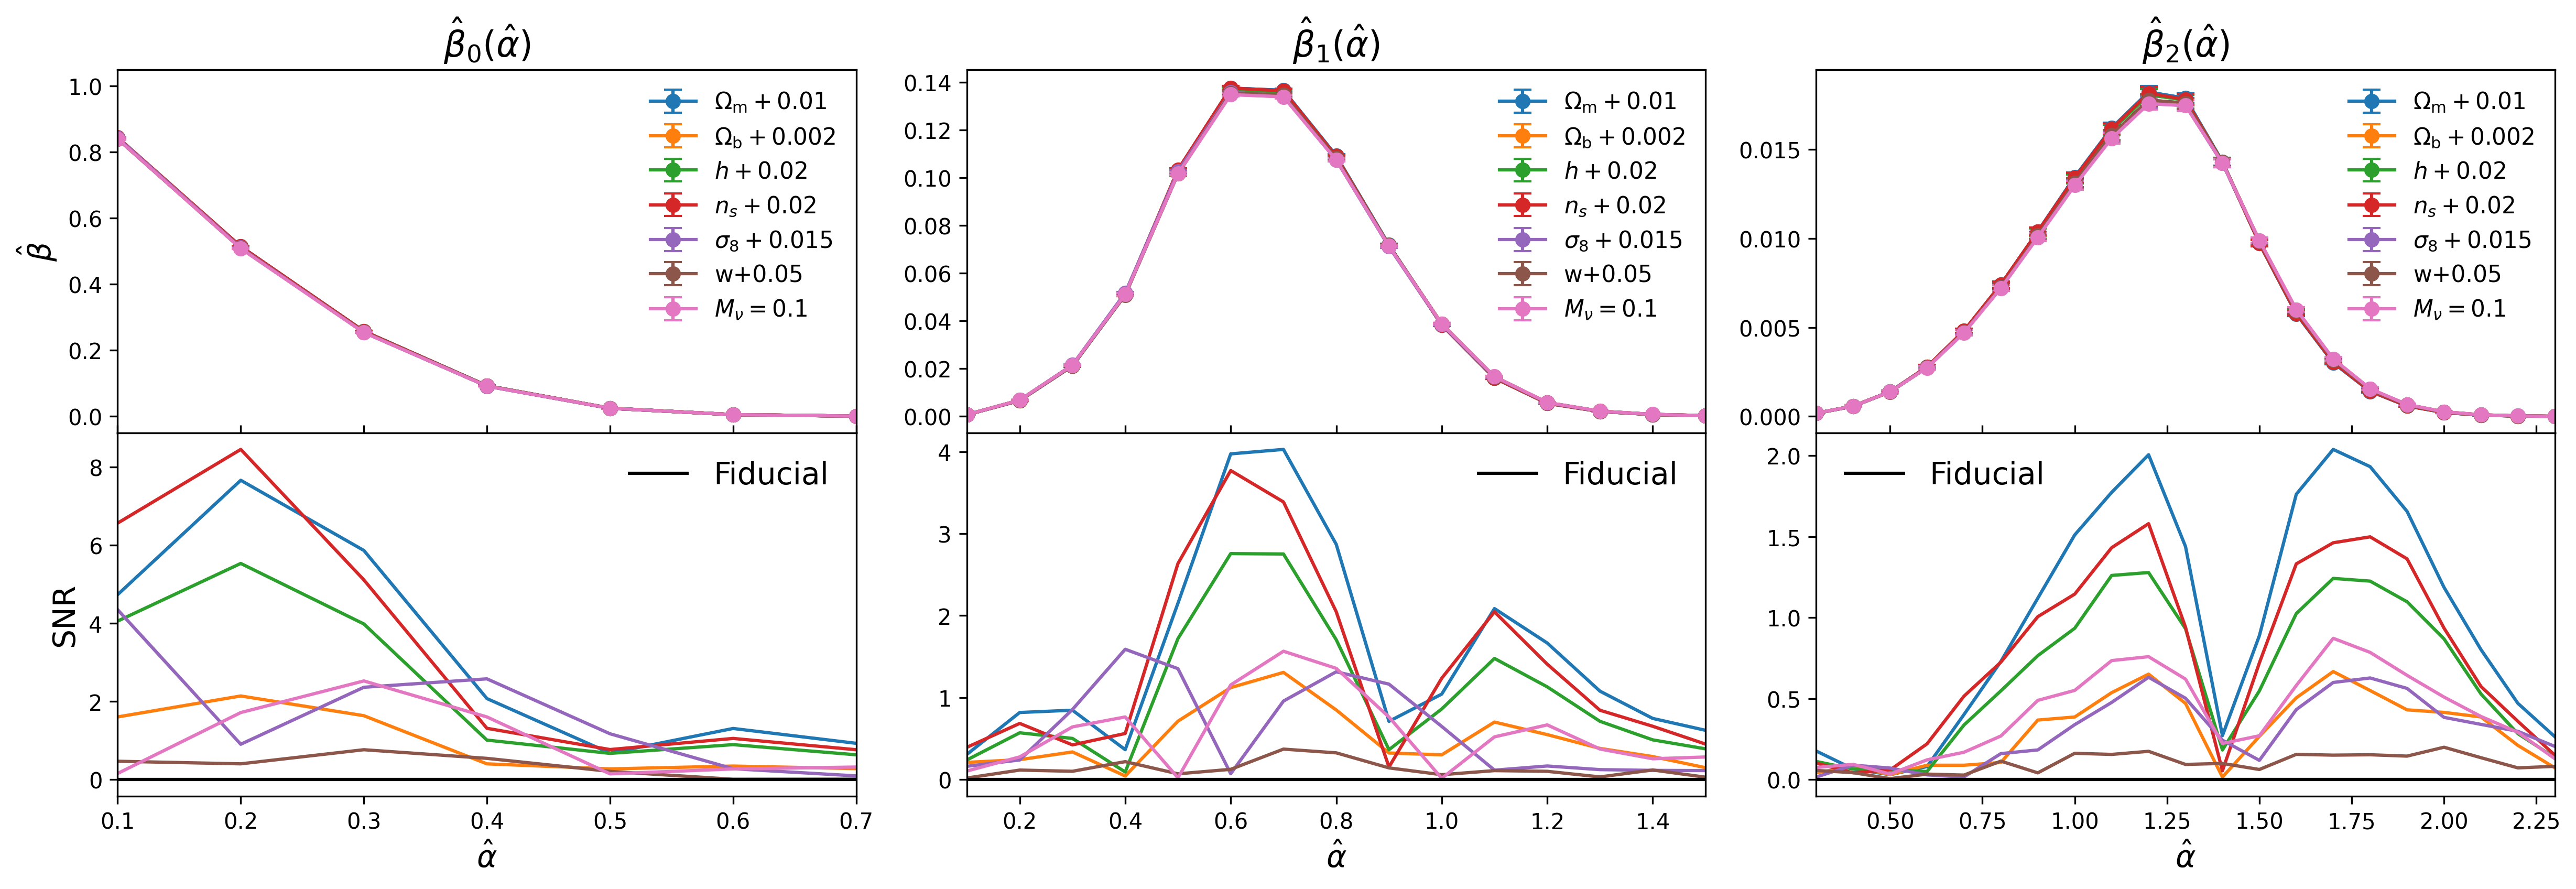

In [31]:
from matplotlib.lines import Line2D

x = np.arange(0,2.5,0.1)
cuts = [range(1,10), range(1,20), range(3,24)]
xlims = [(0.1,0.7),(0.1,1.5),(0.3,2.3)]
data = bcs_fof
data_rsdz = bcs_fof_rsdz

cosmos = ['Om_p', 'Ob2_p', 'h_p', 'ns_p', 's8_p', 'w_p', 'Mnu_p']

labels = [r'$\Omega_{\text{m}}+0.01$', r'$\Omega_{\text{b}}+0.002$', r'$h+0.02$', r'$n_{s}+0.02$', r'$\sigma_8+0.015$']
labelsZA = [r'w+0.05', r'$M_{\nu}=0.1$']

SNR = True
plot_fid = True

fig, axes = plt.subplots(2, 3, sharex='col', gridspec_kw={'height_ratios': [1, 1]}, dpi=300, figsize=(20,6))

for dim in range(3):
    ax1 = axes[0, dim]
    ax2 = axes[1, dim]
    x_cut, test, testZA, test_data, testZA_data, err, errZA, line, lineZA, dot, dotZA = data_for_plot(x, data, cuts, cosmos, dim)
    # x_cut, test_rsdz, testZA_rsdz, test_data_rsdz, testZA_data_rsdz, err_rsdz, errZA_rsdz, line_rsdz, lineZA_rsdz, dot_rsdz, dotZA_rsdz = data_for_plot(x, data_rsdz, cuts, cosmos, dim)

    for i in range(len(test_data)):
        c = ax1.errorbar(x_cut, np.mean(test_data[i],axis=0), yerr=np.std(test_data[i], axis=0), fmt='-o', label=labels[i], capsize=4)[0].get_color()
        # ax1.errorbar(x_cut, np.mean(test_data_rsdz[i],axis=0), yerr=np.std(test_data_rsdz[i], axis=0), fmt='o', capsize=4, color=c)
        ax1.plot(x, np.mean(test[i], axis=0), color=c)
        # ax1.plot(x, np.mean(test_rsdz[i], axis=0), color=c, linestyle='--')
        if SNR:
            ax2.plot(x_cut, np.abs(dot[i]/err[i]), color=c, )
            # ax2.plot(x_cut, np.abs(dot_rsdz[i]/err_rsdz[i]), color=c, linestyle='--')
        else:
            ax2.errorbar(x_cut, dot[i], yerr=err[i], fmt='o', capsize=4, color=c)
            # ax2.errorbar(x_cut, dot_rsdz[i], yerr=err_rsdz[i], fmt='--o', capsize=4, color=c)
            ax2.plot(x, line[i], color=c)
            # ax2.plot(x, line_rsdz[i], color=c, linestyle='--')

    for i in range(len(testZA_data)):
        c = ax1.errorbar(x_cut, np.mean(testZA_data[i],axis=0), yerr=np.std(testZA_data[i], axis=0), fmt='-o', label=labelsZA[i], capsize=4)[0].get_color()
        # ax1.errorbar(x_cut, np.mean(testZA_data_rsdz[i],axis=0), yerr=np.std(testZA_data_rsdz[i], axis=0), fmt='o', capsize=4, color=c)
        ax1.plot(x, np.mean(testZA[i], axis=0), color=c)
        # ax1.plot(x, np.mean(testZA_rsdz[i], axis=0), color=c, linestyle='--')
        if SNR:
            ax2.plot(x_cut, np.abs(dotZA[i]/errZA[i]), color=c, )
            # ax2.plot(x_cut, np.abs(dotZA_rsdz[i]/errZA_rsdz[i]), color=c, linestyle='--')
        else:
            ax2.errorbar(x_cut, dotZA[i], yerr=errZA[i], fmt='o', capsize=4, color=c)
            # ax2.errorbar(x_cut, dotZA_rsdz[i], yerr=errZA_rsdz[i], fmt='--o', capsize=4, color=c)
            ax2.plot(x, lineZA[i], color=c)
            # ax2.plot(x, lineZA_rsdz[i], color=c, linestyle='--')

    xlim = xlims[dim]
    if plot_fid:
        fid_line = ax2.hlines([0], [xlim[0]], [xlim[1]], linestyles=['-'], colors=['k'], label='fiducial') 
        ax2.legend([fid_line], ['Fiducial'], frameon=False, fontsize=14)

    ax1.legend(loc='upper right', frameon=False, fontsize=10.5)
    ax1.tick_params(axis='x', direction='in')

    ax2.set_xlabel(r'$\hat\alpha$', fontsize=14)
    ax2.set_xlim(xlim)

    if dim == 0:
        ax1.set_ylabel(r'$\hat\beta $', fontsize=14)
        if SNR:
            ax2.set_ylabel(r'SNR', fontsize=14)
        else:
            ax2.set_ylabel(r'$(\hat\beta - \hat\beta_{\text{fid}})$', fontsize=14)

    # custom_lines = [
    #     Line2D([0], [0], color='gray', linestyle='-', label='w/o rsd'),
    #     Line2D([0], [0], color='gray', linestyle='--', label='w/ rsd')
    # ]
    # handles, labels_ = ax2.get_legend_handles_labels()
    # handles += custom_lines
    # labels_ += ['w/o rsd', 'w/ rsd']
    # ax2.legend(handles, labels_, frameon=False)
    

    ax1.set_title(rf'$\hat\beta_{dim}(\hat\alpha)$', fontsize=16)
plt.subplots_adjust(hspace=0, wspace=0.15)
plt.savefig('../Fig/sensitivity.pdf', dpi=300, bbox_inches='tight')
plt.show()